# Diabetes Risk Prediction

This notebook trains a simple classifier on the Pima Indians Diabetes dataset to estimate diabetes risk from common health measurements.

It covers a compact baseline workflow: inspect the data, clean invalid values, standardize the features, train Logistic Regression, and evaluate the predictions.

The last section wraps the trained model in a small helper function for single-record predictions.


In [1]:
# Imports
import os

# Avoid Matplotlib cache warnings in restricted environments.
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Plot defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Load data from the local CSV in this directory.
df = pd.read_csv('diabetes.csv')

# Quick sanity check
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Understanding the data

The dataset includes health measurements that are often used when modeling diabetes risk:

- **Pregnancies**: Number of times pregnant
- **Glucose**: Plasma glucose concentration
- **BloodPressure**: Diastolic blood pressure
- **SkinThickness**: Triceps skin fold thickness
- **Insulin**: 2-Hour serum insulin
- **BMI**: Body Mass Index
- **DiabetesPedigreeFunction**: A score based on family history of diabetes
- **Age**: Age of the patient

`Outcome` is the target column: `1` means diabetes and `0` means no diabetes.


In [3]:
# Basic summary stats
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Class balance
print('Class balance (Outcome counts):')
print(df['Outcome'].value_counts())

# Missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# In these columns, zeros usually mean missing or invalid measurements.
zero_check_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nZero values per selected column:')
for col in zero_check_columns:
    print(f'{col}: {(df[col] == 0).sum()}')


Class balance (Outcome counts):
Outcome
0    500
1    268
Name: count, dtype: int64

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values per selected column:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


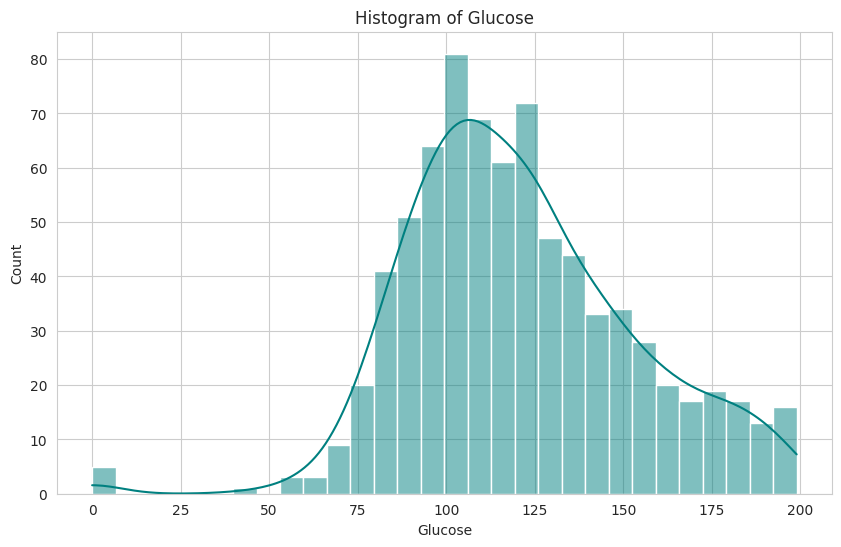

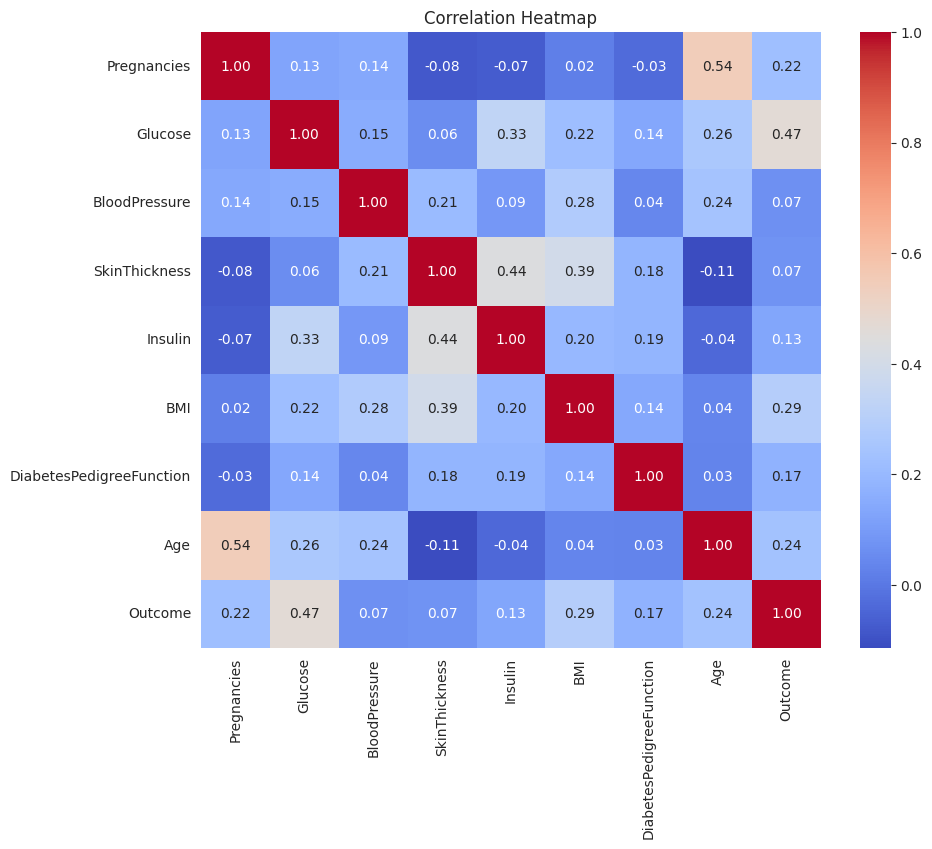

In [5]:
# Plots
# Glucose distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Glucose'], bins=30, kde=True, color='teal')
plt.title('Histogram of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Count')
plt.show()

# Feature correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [6]:
# Preprocessing
# Treat invalid zeros as missing values.
cols_with_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
df_clean[cols_with_invalid_zero] = df_clean[cols_with_invalid_zero].replace(0, np.nan)

# Fill missing values with the column median.
df_clean[cols_with_invalid_zero] = df_clean[cols_with_invalid_zero].fillna(df_clean[cols_with_invalid_zero].median())

# Separate features and target.
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Hold out a test set for evaluation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the scaler on the training data only.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)


Training set shape: (614, 8)
Testing set shape: (154, 8)


In [7]:
# Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print('Model training completed.')


Model training completed.


Accuracy Score: 0.7532

Confusion Matrix:
[[82 17]
 [21 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



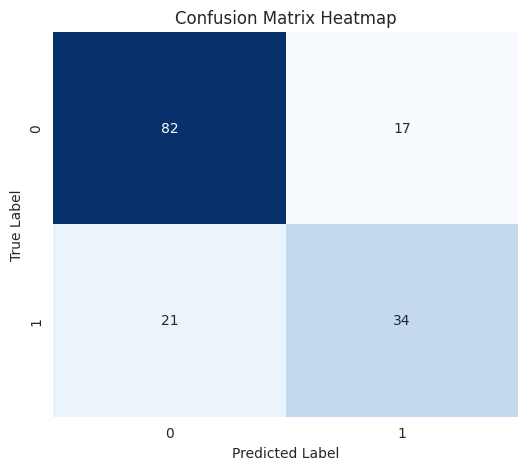

In [8]:
# Evaluation
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

print('\nConfusion Matrix:')
print(cm)

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Feature importance

For Logistic Regression, the learned coefficients show how each feature moves the prediction.
Because the inputs are standardized first, the coefficient magnitudes are easier to compare directly.

- A **positive** coefficient means that increasing the feature tends to increase the predicted diabetes risk.
- A **negative** coefficient means that increasing the feature tends to decrease the predicted diabetes risk.

Larger absolute values usually mean the feature has more influence on the decision boundary.


In [9]:
# Coefficient table
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=lambda s: s.abs(), ascending=False)

coef_df


,Feature,Coefficient
1,Glucose,1.102682
5,BMI,0.688839
7,Age,0.392410
0,Pregnancies,0.222978
6,DiabetesPedigreeFunction,0.203635
2,BloodPressure,-0.151540
4,Insulin,-0.138252
3,SkinThickness,0.068836


In [10]:
# Prediction helper
import ast

def predict_diabetes(user_input):
    # Pass one list with 8 values in this order:
    # [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
    # Example inputs: [2, 120, 70, 20, 79, 25.0, 0.5, 33]
    # Example inputs: [6, 148, 72, 35, 0, 33.6, 0.627, 50]
    input_data = pd.DataFrame([user_input], columns=X.columns)

    # Apply the same preprocessing used during training.
    for col in cols_with_invalid_zero:
        if input_data[col].iloc[0] == 0:
            input_data[col] = df_clean[col].median()

    # Apply the same scaling step.
    input_scaled = scaler.transform(input_data)

    # Probability for class 1 = diabetes.
    probability = model.predict_proba(input_scaled)[0][1]
    prediction = model.predict(input_scaled)[0]

    label = 'High Risk' if prediction == 1 else 'Low Risk'
    return probability, label

raw_input_values = input('Enter 8 values as a list: ')
user_input = ast.literal_eval(raw_input_values)

if len(user_input) != 8:
    raise ValueError('Please enter exactly 8 values.')

probability, label = predict_diabetes(user_input)
print(f'Probability of diabetes: {probability:.2%}')
print(f'Prediction: {label}')


Enter 8 values as a list:  6, 148, 72, 35, 0, 33.6, 0.627, 50


Probability of diabetes: 75.35%
Prediction: High Risk
